In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

print("✅ TensorFlow:", tf.__version__)
print("✅ All imports successful!")

2026-03-29 21:20:13.537396: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ TensorFlow: 2.16.2
✅ All imports successful!


In [2]:
# Image settings
IMG_SIZE = (224, 224)  # MobileNetV2 expects 224x224
BATCH_SIZE = 32

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,           # normalize pixel values 0-1
    rotation_range=20,        # randomly rotate images
    zoom_range=0.2,           # randomly zoom in
    horizontal_flip=True,     # randomly flip left/right
    shear_range=0.2,          # randomly shear images
)

# Validation data generator — no augmentation, just normalize
val_datagen = ImageDataGenerator(rescale=1./255)

# Load images from folders
train_data = train_datagen.flow_from_directory(
    "data/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_data = val_datagen.flow_from_directory(
    "data/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

print("\nClass mapping:", train_data.class_indices)

Found 2019 images belonging to 2 classes.
Found 508 images belonging to 2 classes.

Class mapping: {'landfill': 0, 'recyclable': 1}


In [3]:
# Load MobileNetV2 without its top layer
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,          # remove the original classifier
    weights="imagenet"          # use pre-trained weights
)

# Freeze the base model — don't retrain it
base_model.trainable = False

# Build our custom classifier on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
output = Dense(2, activation="softmax")(x)  # 2 classes

# Create the final model
model = Model(inputs=base_model.input, outputs=output)

# Compile it
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model built successfully!")
print(f"Total layers: {len(model.layers)}")
print(f"Trainable layers: {len([l for l in model.layers if l.trainable])}")

✅ Model built successfully!
Total layers: 158
Trainable layers: 4


In [4]:
# Calculate class weights to handle imbalance
total = 2019
n_landfill = 109
n_recyclable = 1910

weight_landfill = total / (2 * n_landfill)
weight_recyclable = total / (2 * n_recyclable)

class_weights = {
    0: weight_landfill,    # landfill gets higher weight
    1: weight_recyclable   # recyclable gets lower weight
}

print("Class weights:")
print(f"  landfill (0):    {weight_landfill:.2f}")
print(f"  recyclable (1):  {weight_recyclable:.2f}")
print("\n✅ Class weights ready!")

Class weights:
  landfill (0):    9.26
  recyclable (1):  0.53

✅ Class weights ready!


In [5]:
# Train the model
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    class_weight=class_weights
)

print("\n✅ Training complete!")

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.7261 - loss: 0.7399 - val_accuracy: 0.7028 - val_loss: 0.6177
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.8247 - loss: 0.4055 - val_accuracy: 0.9114 - val_loss: 0.2239
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.8648 - loss: 0.3120 - val_accuracy: 0.9213 - val_loss: 0.1897
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.8935 - loss: 0.2468 - val_accuracy: 0.9449 - val_loss: 0.1467
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9029 - loss: 0.2279 - val_accuracy: 0.8642 - val_loss: 0.3415
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9094 - loss: 0.1973 - val_accuracy: 0.9469 - val_loss: 0.1404
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.9247 - loss: 0.1812 - val_accuracy: 0.9488 - val_loss: 0.1274
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.9158 - loss: 0.1884 - val_accuracy: 0.9724 - val_l

In [6]:
# Save the trained model
model.save("model/model.h5")
print("✅ Model saved to model/model.h5")

✅ Model saved to model/model.h5


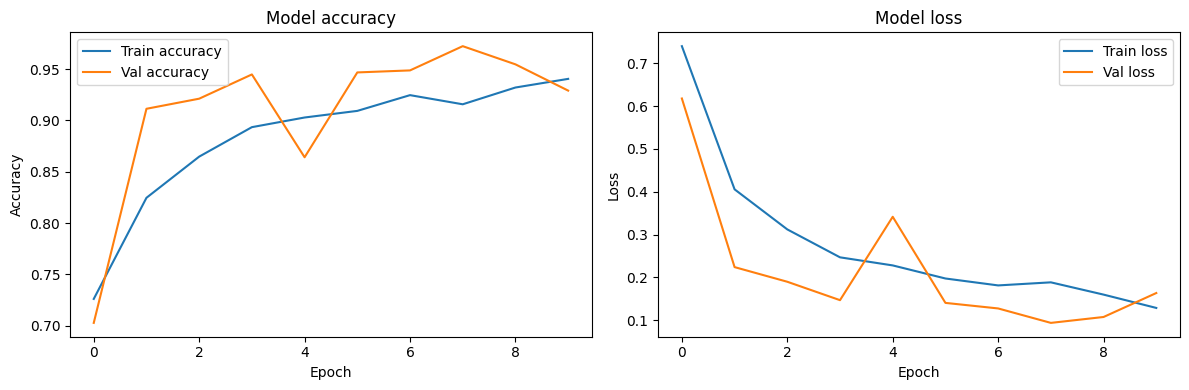

In [7]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(history.history["accuracy"], label="Train accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val accuracy")
axes[0].set_title("Model accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss plot
axes[1].plot(history.history["loss"], label="Train loss")
axes[1].plot(history.history["val_loss"], label="Val loss")
axes[1].set_title("Model loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()